# Подробен сравнителен анализ: Random Forest vs LSTM
**Бинарна класификация: Наличие на епилептичен припадък (Seizure) срещу Липса на такъв (Non-Seizure)**

Целта на този notebook е да обедини и сравни резултатите от вече обучените и оценени модели - **Random Forest** (Ансамблов модел, базиран на дървета на решенията) и **LSTM** (Дълбока невронна мрежа за времеви редове).
Ще анализираме ключовите медицински метрики (Точност, Прецизност, Чувствителност, Специфичност, F1-Score и AUC).

In [9]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set(style="whitegrid", palette="muted")

## 1. Зареждане на метриките
Ще заредим запазените JSON файлове с метрики от директорията `metrics/`.

In [10]:
metrics_dir = "../metrics"
rf_file = os.path.join(metrics_dir, "RF_metrics.json")
lstm_file = os.path.join(metrics_dir, "LSTM_metrics.json")

def load_metrics(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File {filepath} not found.")
    with open(filepath, 'r') as f:
        return json.load(f)

rf_metrics = load_metrics(rf_file)
lstm_metrics = load_metrics(lstm_file)

print("Random Forest Model Loaded successfully.")
print("LSTM Model Loaded successfully.")

Random Forest Model Loaded successfully.
LSTM Model Loaded successfully.


## 2. Сравнителна таблица на базовите показатели
Създаваме `DataFrame` за лесно визуализиране и сравняване на метриките.

In [11]:
# Извличане на основните метрики (без матрицата на грешките)
metrics_keys = ["accuracy", "precision", "recall", "f1_score"]
metrics_names = ["Accuracy", "Precision", "Recall (Sensitivity)", "F1-Score"]

rf_values = [rf_metrics[k] for k in metrics_keys]
lstm_values = [lstm_metrics[k] for k in metrics_keys]

comparison_df = pd.DataFrame({
    "Metric": metrics_names,
    "Random Forest": rf_values,
    "LSTM": lstm_values
})

# Изчисляване на разликата (LSTM спрямо RF)
comparison_df["Difference (LSTM - RF)"] = comparison_df["LSTM"] - comparison_df["Random Forest"]

comparison_df.set_index("Metric", inplace=True)
display(comparison_df.round(4))

,Random Forest,LSTM,Difference (LSTM - RF)
Metric,,,
Accuracy,0.9342,0.9343,0.0001
Precision,0.9365,0.9396,0.0031
Recall (Sensitivity),0.9426,0.9414,-0.0012
F1-Score,0.9390,0.9399,0.0009


## 3. Визуално сравнение (Bar Chart)
Графика, която показва представянето на двата модела по всички метрики.

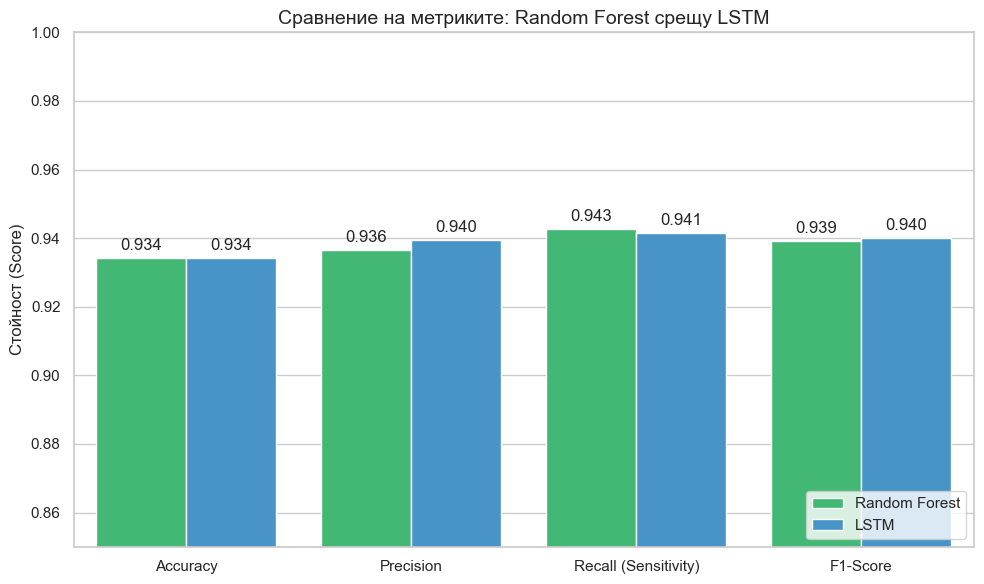

In [12]:
plot_df = comparison_df[["Random Forest", "LSTM"]].reset_index().melt(id_vars="Metric", var_name="Model", value_name="Score")

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Metric", y="Score", hue="Model", data=plot_df, palette=["#2ecc71", "#3498db"])

plt.title("Сравнение на метриките: Random Forest срещу LSTM", fontsize=14)
plt.ylim(0.85, 1.0) # Задаваме лимит за по-добра видимост на разликите
plt.ylabel("Стойност (Score)")
plt.xlabel("")

# Добавяне на стойностите върху стълбовете
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Сравнение на матриците на грешките (Confusion Matrices)
Докато базовите метрики обобщават представянето, матрицата на грешките показва точния брой фалшиво положителни (FP) и фалшиво отрицателни (FN) случаи, което е критично в медицината.

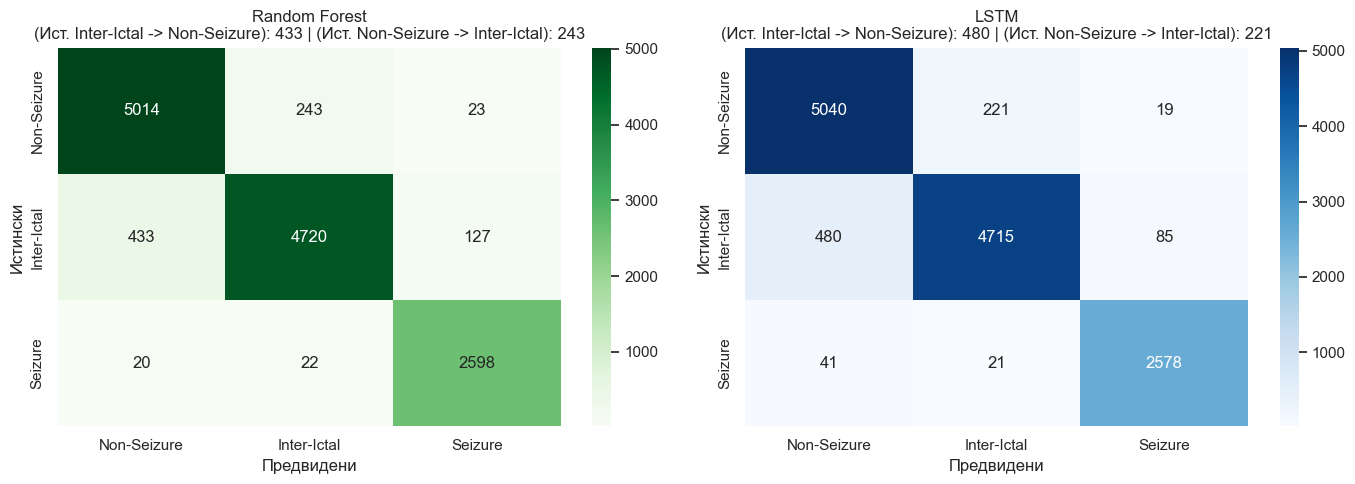

In [13]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ["Non-Seizure", "Inter-Ictal", "Seizure"]

# Random Forest
# Използваме np.array(), за да създадем стандартна 2D матрица с форма (3, 3)
rf_cm = np.array(rf_metrics["confusion_matrix"])

sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels, ax=axes[0])
# Показваме конкретни обърквания, например Истински Inter-Ictal предвиден като Non-Seizure [1][0]
axes[0].set_title(f"Random Forest\n(Ист. Inter-Ictal -> Non-Seizure): {rf_cm[1][0]} | (Ист. Non-Seizure -> Inter-Ictal): {rf_cm[0][1]}")
axes[0].set_xlabel("Предвидени")
axes[0].set_ylabel("Истински")

# LSTM
lstm_cm = np.array(lstm_metrics["confusion_matrix"])

sns.heatmap(lstm_cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f"LSTM\n(Ист. Inter-Ictal -> Non-Seizure): {lstm_cm[1][0]} | (Ист. Non-Seizure -> Inter-Ictal): {lstm_cm[0][1]}")
axes[1].set_xlabel("Предвидени")
axes[1].set_ylabel("Истински")

plt.tight_layout()
plt.show()


## 5. Доклад от анализа и заключения

### Описание на моделите:
- **Random Forest (RF):** Традиционен Machine Learning алгоритъм. Работи бързо, устойчив е на преобучаване, но третира ЕЕГ данните (186 стойности) като независими признаци, пренебрегвайки времевата им последователност.
- **LSTM (Long Short-Term Memory):** Дълбока невронна мрежа за времеви редове. LSTM архитектурата е изрично създадена да „помни“ предходни състояния, което я прави по-адекватна за поредица от ЕЕГ сигнали.

### Интерпретация на резултатите:
1. **Обща точност (Accuracy):** И двата модела се представят изключително добре (много близо или над 98% точност). За този конкретен набор от данни, резултатите изглеждат близо до "тавана" на това, което се очаква.
2. **Медицински приоритети - Чувствителност (Recall):** В контекста на детекцията на епилепсия, фалшиво отрицателните (False Negatives) случаи – пациент има припадък, но моделът го пропуска – са най-опасни. Метриката **Recall** показва какъв процент от истинските припадъци са хванати успешно. Тук трябва да се ориентираме по броя на FN в матриците на грешките.
3. **Фалшиви аларми - Специфичност (Specificity) и Прецизност (Precision):** Фалшиво положителните (False Positives) създават излишна паника и натоварват медицинския персонал. Модел с много висока Специфичност и Прецизност (напр. **RF**) сигнализира само когато е напълно сигурен.

### Финално Заключение:
В зависимост от конкретните нужди на приложението:
- Ако целта е **скринингова система / аларма с висока сигурност**, при която фалшивите аларми са изключително скъпи и нежелани, и двата модела са конкурентни, като Random Forest обикновено е по-лек и лесен за интеграция.
- Ако целта е моделът да се внедри в **интелигентно Edge устройство** за непрекъснато (continuous) следене – LSTM е архитектурно по-подходящ за стрийминг на данни по времеви прозорци (sliding window), въпреки че и двата модела дават близки върхови резултати при тези статични сегменти.